In [313]:
import pandas as pd
import smote_variants as sv

from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
import time




In [314]:
data = pd.read_csv('framingham.csv')

In [315]:
data.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [316]:
# Menghapus kolom target dan kolom yang tidak diperlukan untuk fitur (X)
X = data.drop(['TenYearCHD', 'education'], axis=1) 

# Mengambil kolom target saja untuk (Y)
y = data['TenYearCHD']

In [317]:
y.value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

<Axes: ylabel='count'>

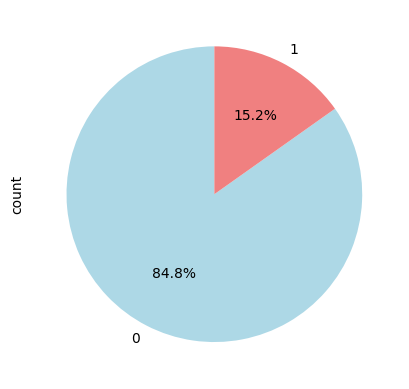

In [318]:
y.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])

In [319]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [320]:
imputer = SimpleImputer(strategy='median')

In [321]:
X_train_imputed = imputer.fit_transform(X_train)

In [322]:
X_test_imputed = imputer.transform(X_test)

In [323]:
svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train_imputed, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [324]:
y_pred_baseline = svm_baseline.predict(X_test_imputed)

In [325]:
print("=== Evaluasi SVM Tanpa Balancing (Baseline) ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

=== Evaluasi SVM Tanpa Balancing (Baseline) ===

Confusion Matrix:
[[1078    1]
 [ 192    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1079
           1       0.50      0.01      0.01       193

    accuracy                           0.85      1272
   macro avg       0.67      0.50      0.46      1272
weighted avg       0.80      0.85      0.78      1272



In [326]:
smote = SMOTE(random_state=42)

In [327]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

<Axes: ylabel='count'>

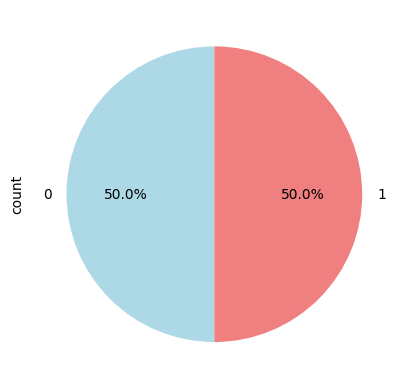

In [328]:
y_train_smote.value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['lightblue', 'lightcoral']
)


In [329]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [330]:
y_pred = svm_model.predict(X_test_imputed)

In [331]:
print("=== Evaluasi SVM Setelah Balancing (SMOTE) ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Membandingkan Akurasi
print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred):.2f}")

=== Evaluasi SVM Setelah Balancing (SMOTE) ===

Confusion Matrix:
[[677 402]
 [ 68 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74      1079
           1       0.24      0.65      0.35       193

    accuracy                           0.63      1272
   macro avg       0.57      0.64      0.54      1272
weighted avg       0.81      0.63      0.68      1272


Final Accuracy: 0.63


In [332]:
print("Memulai proses SMOTE-IPF... (ini mungkin memakan waktu lebih lama dari SMOTE biasa)")
start_time = time.time()

Memulai proses SMOTE-IPF... (ini mungkin memakan waktu lebih lama dari SMOTE biasa)


In [333]:
smote_ipf = sv.SMOTE_IPF()

In [334]:
X_train_smote_ipf, y_train_smote_ipf = smote_ipf.fit_resample(X_train_imputed, y_train)

2026-04-20 12:47:54,701:INFO:SMOTE_IPF: Running sampling via ('SMOTE_IPF', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': None}, 'n_folds': 9, 'k': 3, 'p': 0.01, 'voting': 'majority', 'n_jobs': 1, 'classifier': ('sklearn.tree', 'DecisionTreeClassifier', {'random_state': 2}), 'random_state': None, 'class_name': 'SMOTE_IPF'}")
2026-04-20 12:47:54,702:INFO:SMOTE: Running sampling via ('SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': {}}, 'random_state': None, 'class_name': 'SMOTE'}")
2026-04-20 12:47:54,704:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-20 12:47:54,706:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-20 12:47:54,710:INFO:SMOTE: simplex sampling with n_

In [335]:
end_time = time.time()
print(f"Proses SMOTE-IPF selesai dalam {end_time - start_time:.2f} detik.")

Proses SMOTE-IPF selesai dalam 1.29 detik.


In [336]:
y_pred_ipf = svm_model.predict(X_test_imputed)

In [337]:
# Menampilkan Hasil
print("=== Evaluasi SVM Setelah SMOTE-IPF ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ipf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ipf))

print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred_ipf):.2f}")

# Opsional: Cek jumlah data setelah SMOTE-IPF
print(f"\nJumlah data kelas 0 dan 1 setelah SMOTE-IPF:")
print(pd.Series(y_train_smote_ipf).value_counts())

=== Evaluasi SVM Setelah SMOTE-IPF ===

Confusion Matrix:
[[677 402]
 [ 68 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74      1079
           1       0.24      0.65      0.35       193

    accuracy                           0.63      1272
   macro avg       0.57      0.64      0.54      1272
weighted avg       0.81      0.63      0.68      1272


Final Accuracy: 0.63

Jumlah data kelas 0 dan 1 setelah SMOTE-IPF:
0    2517
1    2517
Name: count, dtype: int64


In [338]:
smote_ipf_tuned = sv.SMOTE_IPF(n_folds=5, n_neighbors=5, k=3, voting='majority', random_state=42)

In [339]:
X_train_tuned, y_train_tuned = smote_ipf_tuned.sample(X_train_imputed, y_train)

2026-04-20 12:47:56,475:INFO:SMOTE_IPF: Running sampling via ('SMOTE_IPF', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': None}, 'n_folds': 5, 'k': 3, 'p': 0.01, 'voting': 'majority', 'n_jobs': 1, 'classifier': ('sklearn.tree', 'DecisionTreeClassifier', {'random_state': 2}), 'random_state': 42, 'class_name': 'SMOTE_IPF'}")
2026-04-20 12:47:56,477:INFO:SMOTE: Running sampling via ('SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': {}}, 'random_state': 42, 'class_name': 'SMOTE'}")
2026-04-20 12:47:56,479:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-20 12:47:56,481:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-04-20 12:47:56,485:INFO:SMOTE: simplex sampling with n_dim 

In [340]:
print("Jumlah data kelas 0 dan 1 SETELAH di-tuning:")
print(pd.Series(y_train_tuned).value_counts())

Jumlah data kelas 0 dan 1 SETELAH di-tuning:
0    2517
1    2517
Name: count, dtype: int64


In [341]:
end_time = time.time()
print(f"Proses selesai dalam {end_time - start_time:.2f} detik.\n")

Proses selesai dalam 2.47 detik.



In [342]:
# --- 2. HYPERPARAMETER TUNING SVM DENGAN GRIDSEARCHCV ---
print("2. Memulai pencarian parameter SVM terbaik (GridSearchCV)... ini akan memakan waktu.")

# Menentukan parameter apa saja yang akan dicoba
param_grid = {
    'C': [1, 5, 10, 50],              # Rentang C diperketat
    'gamma': [0.01, 0.05, 0.1, 'scale'], 
    'kernel': ['rbf']                  # Kita fokus di RBF dulu karena biasanya paling kuat
}

2. Memulai pencarian parameter SVM terbaik (GridSearchCV)... ini akan memakan waktu.


In [343]:
grid_search = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5, n_jobs=-1, scoring='recall')

In [344]:
grid_search.fit(X_train_tuned, y_train_tuned)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [1, 5, ...], 'gamma': [0.01, 0.05, ...], 'kernel': ['rbf']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,50


In [345]:
print("\nParameter SVM Terbaik yang ditemukan:")
print(grid_search.best_params_)


Parameter SVM Terbaik yang ditemukan:
{'C': 50, 'gamma': 0.01, 'kernel': 'rbf'}


In [346]:
print("\n3. Evaluasi Akhir...")


3. Evaluasi Akhir...


In [347]:
y_pred_best = grid_search.predict(X_test_imputed)

In [348]:
print("\n=== Evaluasi SVM Terbaik (SMOTE-IPF Tuned + GridSearchCV) ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

final_acc = accuracy_score(y_test, y_pred_best)
print(f"\nFinal Accuracy: {final_acc:.2f} ({final_acc * 100:.1f}%)")


=== Evaluasi SVM Terbaik (SMOTE-IPF Tuned + GridSearchCV) ===

Confusion Matrix:
[[1019   60]
 [ 179   14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.90      1079
           1       0.19      0.07      0.10       193

    accuracy                           0.81      1272
   macro avg       0.52      0.51      0.50      1272
weighted avg       0.75      0.81      0.78      1272


Final Accuracy: 0.81 (81.2%)


In [349]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
xgb = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=1)

In [350]:
voting_model = VotingClassifier(
   estimators=[('svm', grid_search), ('rf', rf), ('xgb', xgb)],
    voting='hard' # Mengambil suara terbanyak
)

In [351]:
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Voting Ensemble": voting_model
}

In [312]:
for name, model in models.items():
    model.fit(X_train_tuned, y_train_tuned)
    y_pred = model.predict(X_test_imputed)
    
    print(f"=== Evaluasi {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

=== Evaluasi Random Forest ===
Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1079
           1       0.33      0.19      0.24       193

    accuracy                           0.82      1272
   macro avg       0.60      0.56      0.57      1272
weighted avg       0.78      0.82      0.80      1272

------------------------------
=== Evaluasi XGBoost ===
Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1079
           1       0.27      0.17      0.21       193

    accuracy                           0.80      1272
   macro avg       0.56      0.54      0.55      1272
weighted avg       0.77      0.80      0.78      1272

------------------------------
=== Evaluasi Voting Ensemble ===
Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1079
           1       0.34      0.14      0.